In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel
)

# --------------------------------------------------
# Function 2 - Week 8 Bayesian Optimisation
# --------------------------------------------------
#
# Strategy:
# - maximise raw objective
# - fit ARD Matern GP to all observations through Week 7
# - optimise GP hyperparameters automatically
# - derive candidate-search widths from fitted ARD lengthscales
# - search local + wide + dense global space
# - use EI as the primary acquisition
# - compare UCB and highest GP mean as diagnostics
#
# No manual centring on a specific previous week.

In [2]:
X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy").reshape(-1)

assert len(X) == len(Y)
assert X.shape[1] == 2

print("X shape:", X.shape)
print("Y shape:", Y.shape)

best_idx = np.argmax(Y)
best_x = X[best_idx]
best_y = Y[best_idx]

print("\nCurrent best observed input:")
print(best_x)

print("\nCurrent best observed output:")
print(best_y)

print("\nY range:")
print("min =", np.min(Y))
print("max =", np.max(Y))
print("std =", np.std(Y))

X shape: (17, 2)
Y shape: (17,)

Current best observed input:
[0.711177 1.      ]

Current best observed output:
0.679662733033218

Y range:
min = -0.06562362443733738
max = 0.679662733033218
std = 0.24539352931986558


In [3]:
kernel = (
    ConstantKernel(
        1.0,
        constant_value_bounds=(1e-3, 1e3)
    )
    *
    Matern(
        length_scale=np.ones(2) * 0.2,
        length_scale_bounds=(0.01, 2.0),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(1e-8, 1e-1)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(X, Y)

print("\nFitted kernel:")
print(gp.kernel_)


Fitted kernel:
0.997**2 * Matern(length_scale=[0.0547, 2], nu=2.5) + WhiteKernel(noise_level=0.0548)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
lengthscales = gp.kernel_.k1.k2.length_scale

inverse_ls = 1.0 / lengthscales
relative_sensitivity = inverse_ls / inverse_ls.sum()

print("\nARD lengthscales:")
print(lengthscales)

print("\nNormalised inverse-lengthscale sensitivity:")
print(relative_sensitivity)


ARD lengthscales:
[0.05469119 2.        ]

Normalised inverse-lengthscale sensitivity:
[0.97338228 0.02661772]


In [5]:
local_scale = np.clip(
    0.25 * lengthscales,
    0.015,
    0.10
)

wide_scale = np.clip(
    0.50 * lengthscales,
    0.04,
    0.20
)

print("\nLocal widths:", local_scale)
print("Wide widths:", wide_scale)


Local widths: [0.015 0.1  ]
Wide widths: [0.04 0.2 ]


In [6]:
rng = np.random.default_rng(42)

local_candidates = (
    best_x
    + rng.normal(
        0,
        local_scale,
        size=(30000, 2)
    )
)

wide_candidates = (
    best_x
    + rng.normal(
        0,
        wide_scale,
        size=(20000, 2)
    )
)

local_candidates = np.clip(
    local_candidates,
    0,
    1
)

wide_candidates = np.clip(
    wide_candidates,
    0,
    1
)

In [7]:
grid_axis = np.linspace(
    0,
    1,
    401
)

g1, g2 = np.meshgrid(
    grid_axis,
    grid_axis
)

global_candidates = np.column_stack([
    g1.ravel(),
    g2.ravel()
])

print(
    "Global grid candidates:",
    len(global_candidates)
)

Global grid candidates: 160801


In [8]:
candidates = np.vstack([
    local_candidates,
    wide_candidates,
    global_candidates
])

print(
    "Total candidates before filtering:",
    len(candidates)
)

Total candidates before filtering: 210801


In [9]:
tree = cKDTree(X)

distance, _ = tree.query(
    candidates,
    k=1
)

candidates = candidates[
    distance > 0.01
]

print(
    "Candidates after filtering:",
    len(candidates)
)

Candidates after filtering: 196385


In [10]:
mu, sigma = gp.predict(
    candidates,
    return_std=True
)

print("Prediction complete.")

Prediction complete.


In [11]:
def expected_improvement(
    mu,
    sigma,
    best_y,
    xi=0.0
):

    improvement = (
        mu
        - best_y
        - xi
    )

    Z = np.zeros_like(mu)

    valid = sigma > 1e-12

    Z[valid] = (
        improvement[valid]
        / sigma[valid]
    )

    EI = np.zeros_like(mu)

    EI[valid] = (
        improvement[valid]
        * norm.cdf(Z[valid])
        +
        sigma[valid]
        * norm.pdf(Z[valid])
    )

    return EI

In [12]:
EI = expected_improvement(
    mu,
    sigma,
    best_y,
    xi=0.0
)

ei_idx = np.argmax(EI)

print("\nPRIMARY EI RESULT")

print("candidate =", candidates[ei_idx])
print("mean =", mu[ei_idx])
print("std =", sigma[ei_idx])
print("EI =", EI[ei_idx])


PRIMARY EI RESULT
candidate = [0.7 0. ]
mean = 0.6345539886354703
std = 0.12008561962793432
EI = 0.028693620896554382


In [13]:
y_scale = np.std(Y)

xi_values = [
    0.0,
    0.01 * y_scale,
    0.05 * y_scale,
    0.10 * y_scale
]

print("\nEI sensitivity check:\n")

for xi in xi_values:

    EI_test = expected_improvement(
        mu,
        sigma,
        best_y,
        xi
    )

    idx = np.argmax(EI_test)

    print(
        "xi =", f"{xi:.6e}",
        "\n candidate =", candidates[idx],
        "\n mean =", round(mu[idx], 6),
        "\n std =", round(sigma[idx], 6),
        "\n EI =", round(EI_test[idx], 8),
        "\n"
    )


EI sensitivity check:

xi = 0.000000e+00 
 candidate = [0.7 0. ] 
 mean = 0.634554 
 std = 0.120086 
 EI = 0.02869362 

xi = 2.453935e-03 
 candidate = [0.7 0. ] 
 mean = 0.634554 
 std = 0.120086 
 EI = 0.02783522 

xi = 1.226968e-02 
 candidate = [0.7 0. ] 
 mean = 0.634554 
 std = 0.120086 
 EI = 0.02458503 

xi = 2.453935e-02 
 candidate = [0.7 0. ] 
 mean = 0.634554 
 std = 0.120086 
 EI = 0.02092232 



In [14]:
print("\nUCB diagnostic:\n")

for beta in [
    0.1,
    0.25,
    0.5,
    1.0
]:

    UCB = mu + beta * sigma

    idx = np.argmax(UCB)

    print(
        f"beta={beta}",
        "\n candidate =", candidates[idx],
        "\n mean =", round(mu[idx], 6),
        "\n std =", round(sigma[idx], 6),
        "\n UCB =", round(UCB[idx], 6),
        "\n"
    )


UCB diagnostic:

beta=0.1 
 candidate = [0.6975 0.2175] 
 mean = 0.640296 
 std = 0.103262 
 UCB = 0.650622 

beta=0.25 
 candidate = [0.6975 0.1275] 
 mean = 0.639225 
 std = 0.109325 
 UCB = 0.666556 

beta=0.5 
 candidate = [0.6975 0.    ] 
 mean = 0.636137 
 std = 0.118048 
 UCB = 0.695161 

beta=1.0 
 candidate = [0.7 0. ] 
 mean = 0.634554 
 std = 0.120086 
 UCB = 0.75464 



In [15]:
mean_idx = np.argmax(mu)

print("\nHighest predicted mean:")
print("candidate =", candidates[mean_idx])
print("mean =", mu[mean_idx])
print("std =", sigma[mean_idx])


Highest predicted mean:
candidate = [0.6975 0.2725]
mean = 0.6404831880199174
std = 0.099622533271664


In [16]:
# --------------------------------------------------
# Function 2 - ARD trust-region search
# --------------------------------------------------
#
# Global EI moves to x2 = 0 despite a lower predicted mean,
# indicating that uncertainty is strongly influencing the acquisition.
#
# We therefore optimise the acquisition inside a trust region centred
# automatically on the current best observation.
#
# Trust-region widths are derived from the fitted ARD lengthscales,
# not manually chosen around a particular week.

trust_half_width = np.clip(
    0.5 * lengthscales,
    0.025,
    0.15
)

lower = np.maximum(
    0.0,
    best_x - trust_half_width
)

upper = np.minimum(
    1.0,
    best_x + trust_half_width
)

print("Current best:", best_x)
print("ARD lengthscales:", lengthscales)
print("Trust-region half widths:", trust_half_width)
print("Lower bounds:", lower)
print("Upper bounds:", upper)

Current best: [0.711177 1.      ]
ARD lengthscales: [0.05469119 2.        ]
Trust-region half widths: [0.02734559 0.15      ]
Lower bounds: [0.68383141 0.85      ]
Upper bounds: [0.73852259 1.        ]


In [17]:
x1_axis = np.linspace(
    lower[0],
    upper[0],
    501
)

x2_axis = np.linspace(
    lower[1],
    upper[1],
    501
)

g1, g2 = np.meshgrid(
    x1_axis,
    x2_axis
)

tr_candidates = np.column_stack([
    g1.ravel(),
    g2.ravel()
])

# Remove near-duplicates of existing observations
tree = cKDTree(X)

distance, _ = tree.query(
    tr_candidates,
    k=1
)

tr_candidates = tr_candidates[
    distance > 0.01
]

print(
    "Trust-region candidates:",
    len(tr_candidates)
)

Trust-region candidates: 225444


In [18]:
tr_mu, tr_sigma = gp.predict(
    tr_candidates,
    return_std=True
)

In [19]:
tr_EI = expected_improvement(
    tr_mu,
    tr_sigma,
    best_y,
    xi=0.0
)

ei_idx = np.argmax(tr_EI)

print("\nTrust-region EI:")
print("candidate =", tr_candidates[ei_idx])
print("mean =", tr_mu[ei_idx])
print("std =", tr_sigma[ei_idx])
print("EI =", tr_EI[ei_idx])


Trust-region EI:
candidate = [0.69728544 0.85      ]
mean = 0.6197295280832331
std = 0.07315117367873455
EI = 0.008498032967500043


In [20]:
mean_idx = np.argmax(tr_mu)

print("\nTrust-region highest predicted mean:")
print("candidate =", tr_candidates[mean_idx])
print("mean =", tr_mu[mean_idx])
print("std =", tr_sigma[mean_idx])

print("\nTrust-region UCB:\n")

for beta in [0.1, 0.25, 0.5, 1.0]:

    UCB = tr_mu + beta * tr_sigma
    idx = np.argmax(UCB)

    print(
        f"beta={beta}",
        "\n candidate =", tr_candidates[idx],
        "\n mean =", round(tr_mu[idx], 6),
        "\n std =", round(tr_sigma[idx], 6),
        "\n UCB =", round(UCB[idx], 6),
        "\n"
    )


Trust-region highest predicted mean:
candidate = [0.70264517 0.85      ]
mean = 0.6243055044395819
std = 0.0674704290755464

Trust-region UCB:

beta=0.1 
 candidate = [0.70242641 0.85      ] 
 mean = 0.624297 
 std = 0.067656 
 UCB = 0.631062 

beta=0.25 
 candidate = [0.70198888 0.85      ] 
 mean = 0.624233 
 std = 0.068041 
 UCB = 0.641244 

beta=0.5 
 candidate = [0.70111382 0.85      ] 
 mean = 0.623926 
 std = 0.068864 
 UCB = 0.658358 

beta=1.0 
 candidate = [0.69903556 0.85      ] 
 mean = 0.622224 
 std = 0.07107 
 UCB = 0.693294 



In [21]:
# --------------------------------------------------
# Function 2 - adaptive trust-region expansion
# --------------------------------------------------
#
# All trust-region acquisitions selected the lower x2 boundary.
# This indicates that the current trust region is truncating the search.
#
# Formal rule:
# if the primary EI optimum lies on a trust-region boundary,
# expand that dimension's half-width by a factor of 2.
#
# x1 remains unchanged because the optimiser is not hitting its boundary.

expanded_half_width = trust_half_width.copy()

tol = 1e-8
ei_candidate = tr_candidates[ei_idx]

# Expand only dimensions where EI hits a boundary
for j in range(X.shape[1]):

    hit_lower = abs(ei_candidate[j] - lower[j]) < tol
    hit_upper = abs(ei_candidate[j] - upper[j]) < tol

    if hit_lower or hit_upper:
        expanded_half_width[j] = min(
            2.0 * trust_half_width[j],
            0.50
        )

expanded_lower = np.maximum(
    0.0,
    best_x - expanded_half_width
)

expanded_upper = np.minimum(
    1.0,
    best_x + expanded_half_width
)

print("Original half-widths:", trust_half_width)
print("Expanded half-widths:", expanded_half_width)

print("\nExpanded lower bounds:", expanded_lower)
print("Expanded upper bounds:", expanded_upper)

Original half-widths: [0.02734559 0.15      ]
Expanded half-widths: [0.02734559 0.3       ]

Expanded lower bounds: [0.68383141 0.7       ]
Expanded upper bounds: [0.73852259 1.        ]


In [22]:
x1_axis = np.linspace(
    expanded_lower[0],
    expanded_upper[0],
    501
)

x2_axis = np.linspace(
    expanded_lower[1],
    expanded_upper[1],
    501
)

g1, g2 = np.meshgrid(
    x1_axis,
    x2_axis
)

exp_candidates = np.column_stack([
    g1.ravel(),
    g2.ravel()
])

# Remove points too close to existing observations
tree = cKDTree(X)

distance, _ = tree.query(
    exp_candidates,
    k=1
)

exp_candidates = exp_candidates[
    distance > 0.01
]

print(
    "Expanded trust-region candidates:",
    len(exp_candidates)
)

Expanded trust-region candidates: 233383


In [23]:
exp_mu, exp_sigma = gp.predict(
    exp_candidates,
    return_std=True
)

In [24]:
exp_EI = expected_improvement(
    exp_mu,
    exp_sigma,
    best_y,
    xi=0.0
)

exp_ei_idx = np.argmax(exp_EI)

print("\nExpanded trust-region EI:")
print("candidate =", exp_candidates[exp_ei_idx])
print("mean =", exp_mu[exp_ei_idx])
print("std =", exp_sigma[exp_ei_idx])
print("EI =", exp_EI[exp_ei_idx])


Expanded trust-region EI:
candidate = [0.69826988 0.7       ]
mean = 0.6302222981269492
std = 0.07566828726652994
EI = 0.011690881245897221


In [25]:
exp_mean_idx = np.argmax(exp_mu)

print("\nExpanded trust-region highest mean:")
print("candidate =", exp_candidates[exp_mean_idx])
print("mean =", exp_mu[exp_mean_idx])
print("std =", exp_sigma[exp_mean_idx])


Expanded trust-region highest mean:
candidate = [0.70166073 0.7       ]
mean = 0.6319399377354584
std = 0.07318175611394678


In [26]:
print("\nExpanded trust-region UCB:\n")

for beta in [0.1, 0.25, 0.5, 1.0]:

    UCB = exp_mu + beta * exp_sigma
    idx = np.argmax(UCB)

    print(
        f"beta={beta}",
        "\n candidate =", exp_candidates[idx],
        "\n mean =", round(exp_mu[idx], 6),
        "\n std =", round(exp_sigma[idx], 6),
        "\n UCB =", round(UCB[idx], 6),
        "\n"
    )


Expanded trust-region UCB:

beta=0.1 
 candidate = [0.70144197 0.7       ] 
 mean = 0.631936 
 std = 0.073323 
 UCB = 0.639268 

beta=0.25 
 candidate = [0.70100444 0.7       ] 
 mean = 0.631884 
 std = 0.073615 
 UCB = 0.650288 

beta=0.5 
 candidate = [0.70045753 0.7       ] 
 mean = 0.631736 
 std = 0.073995 
 UCB = 0.668734 

beta=1.0 
 candidate = [0.69903556 0.7       ] 
 mean = 0.630921 
 std = 0.075058 
 UCB = 0.705978 



In [27]:
# --------------------------------------------------
# Function 2 - final adaptive trust-region expansion
# --------------------------------------------------
#
# The expanded trust-region optimum is still on the
# lower x2 boundary, so expand x2 once more.
#
# x1 remains tightly constrained because the GP
# estimates much faster variation in x1.

final_half_width = expanded_half_width.copy()

# Expand only x2 again
final_half_width[1] = min(
    2.0 * expanded_half_width[1],
    1.0
)

final_lower = np.maximum(
    0.0,
    best_x - final_half_width
)

final_upper = np.minimum(
    1.0,
    best_x + final_half_width
)

print("Final half-widths:", final_half_width)
print("Final lower bounds:", final_lower)
print("Final upper bounds:", final_upper)

Final half-widths: [0.02734559 0.6       ]
Final lower bounds: [0.68383141 0.4       ]
Final upper bounds: [0.73852259 1.        ]


In [28]:
x1_axis = np.linspace(
    final_lower[0],
    final_upper[0],
    501
)

x2_axis = np.linspace(
    final_lower[1],
    final_upper[1],
    601
)

g1, g2 = np.meshgrid(
    x1_axis,
    x2_axis
)

final_candidates = np.column_stack([
    g1.ravel(),
    g2.ravel()
])

tree = cKDTree(X)

distance, _ = tree.query(
    final_candidates,
    k=1
)

final_candidates = final_candidates[
    distance > 0.01
]

final_mu, final_sigma = gp.predict(
    final_candidates,
    return_std=True
)

In [29]:
# EI
final_EI = expected_improvement(
    final_mu,
    final_sigma,
    best_y,
    xi=0.0
)

ei_idx = np.argmax(final_EI)

print("\nFinal expanded EI:")
print("candidate =", final_candidates[ei_idx])
print("mean =", final_mu[ei_idx])
print("std =", final_sigma[ei_idx])
print("EI =", final_EI[ei_idx])


# Highest mean
mean_idx = np.argmax(final_mu)

print("\nFinal expanded highest mean:")
print("candidate =", final_candidates[mean_idx])
print("mean =", final_mu[mean_idx])
print("std =", final_sigma[mean_idx])


# UCB
print("\nFinal expanded UCB:\n")

for beta in [0.1, 0.25, 0.5, 1.0]:

    UCB = final_mu + beta * final_sigma
    idx = np.argmax(UCB)

    print(
        f"beta={beta}",
        "\n candidate =", final_candidates[idx],
        "\n mean =", round(final_mu[idx], 6),
        "\n std =", round(final_sigma[idx], 6),
        "\n UCB =", round(UCB[idx], 6),
        "\n"
    )


Final expanded EI:
candidate = [0.6993637 0.4      ]
mean = 0.6399714059543298
std = 0.09156886413201468
EI = 0.02006410016083588

Final expanded highest mean:
candidate = [0.69925432 0.4       ]
mean = 0.6399718567037336
std = 0.0915654796688915

Final expanded UCB:

beta=0.1 
 candidate = [0.69925432 0.4       ] 
 mean = 0.639972 
 std = 0.091565 
 UCB = 0.649128 

beta=0.25 
 candidate = [0.6993637 0.4      ] 
 mean = 0.639971 
 std = 0.091569 
 UCB = 0.662864 

beta=0.5 
 candidate = [0.6993637 0.4      ] 
 mean = 0.639971 
 std = 0.091569 
 UCB = 0.685756 

beta=1.0 
 candidate = [0.6993637 0.4      ] 
 mean = 0.639971 
 std = 0.091569 
 UCB = 0.73154 



In [30]:
# --------------------------------------------------
# Function 2 - final ARD-informed search
# --------------------------------------------------
#
# Repeated trust-region expansions hit the lower x2 boundary.
# The fitted GP also gives x2 the maximum ARD lengthscale,
# indicating relatively smooth behaviour in that direction.
#
# Therefore:
# - retain the ARD-based local restriction on sensitive x1
# - allow smoother x2 to cover its complete [0, 1] range

x1_half_width = trust_half_width[0]

search_lower = np.array([
    max(0.0, best_x[0] - x1_half_width),
    0.0
])

search_upper = np.array([
    min(1.0, best_x[0] + x1_half_width),
    1.0
])

print("Final search lower:", search_lower)
print("Final search upper:", search_upper)

Final search lower: [0.68383141 0.        ]
Final search upper: [0.73852259 1.        ]


In [31]:
x1_axis = np.linspace(
    search_lower[0],
    search_upper[0],
    501
)

x2_axis = np.linspace(
    0.0,
    1.0,
    1001
)

g1, g2 = np.meshgrid(
    x1_axis,
    x2_axis
)

search_candidates = np.column_stack([
    g1.ravel(),
    g2.ravel()
])

# Remove existing/near-duplicate observations
tree = cKDTree(X)

distance, _ = tree.query(
    search_candidates,
    k=1
)

search_candidates = search_candidates[
    distance > 0.01
]

print("Final search candidates:", len(search_candidates))

Final search candidates: 490886


In [32]:
search_mu, search_sigma = gp.predict(
    search_candidates,
    return_std=True
)

In [33]:
search_EI = expected_improvement(
    search_mu,
    search_sigma,
    best_y,
    xi=0.0
)

ei_idx = np.argmax(search_EI)

print("\nFINAL EI:")
print("candidate =", search_candidates[ei_idx])
print("mean =", search_mu[ei_idx])
print("std =", search_sigma[ei_idx])
print("EI =", search_EI[ei_idx])


FINAL EI:
candidate = [0.69958247 0.        ]
mean = 0.634920077044286
std = 0.11976423022094951
EI = 0.028703678973489386


In [34]:
mean_idx = np.argmax(search_mu)

print("\nFINAL highest predicted mean:")
print("candidate =", search_candidates[mean_idx])
print("mean =", search_mu[mean_idx])
print("std =", search_sigma[mean_idx])


FINAL highest predicted mean:
candidate = [0.69837926 0.29      ]
mean = 0.6405778262049429
std = 0.09875625446294681


In [35]:
print("\nFINAL UCB:\n")

for beta in [0.1, 0.25, 0.5, 1.0]:

    UCB = search_mu + beta * search_sigma
    idx = np.argmax(UCB)

    print(
        f"beta={beta}",
        "\n candidate =", search_candidates[idx],
        "\n mean =", round(search_mu[idx], 6),
        "\n std =", round(search_sigma[idx], 6),
        "\n UCB =", round(UCB[idx], 6),
        "\n"
    )


FINAL UCB:

beta=0.1 
 candidate = [0.69805111 0.227     ] 
 mean = 0.640371 
 std = 0.102884 
 UCB = 0.650659 

beta=0.25 
 candidate = [0.69772297 0.132     ] 
 mean = 0.639273 
 std = 0.109166 
 UCB = 0.666564 

beta=0.5 
 candidate = [0.69783235 0.        ] 
 mean = 0.636012 
 std = 0.118335 
 UCB = 0.695179 

beta=1.0 
 candidate = [0.6993637 0.       ] 
 mean = 0.635096 
 std = 0.119593 
 UCB = 0.754689 



In [36]:
# --------------------------------------------------
# Final Function 2 Week 8 selection
# --------------------------------------------------
#
# Standard EI selected x2 = 0, where predictive uncertainty is
# highest and the predicted mean is lower than at interior points.
#
# Increasing UCB beta also progressively moved the recommendation
# towards x2 = 0, confirming that the boundary behaviour is driven
# increasingly by uncertainty.
#
# The highest GP mean occurred at an interior point near
# [0.6984, 0.2900]. Low-exploration UCB (beta=0.1) selected a
# nearby interior point with almost the same predicted mean.
#
# Therefore beta=0.1 UCB is used as the final acquisition rule,
# retaining a small uncertainty component without allowing it to
# dominate the recommendation.

beta = 0.1

UCB = search_mu + beta * search_sigma
final_idx = np.argmax(UCB)

week8_candidate = search_candidates[final_idx]

print("Week 8 Function 2 candidate:")
print(week8_candidate)

print("\nPredicted mean:")
print(search_mu[final_idx])

print("\nPredicted std:")
print(search_sigma[final_idx])

print("\nUCB:")
print(UCB[final_idx])

portal = "-".join(
    f"{x:.6f}"
    for x in week8_candidate
)

print("\nPortal format:")
print(portal)

Week 8 Function 2 candidate:
[0.69805111 0.227     ]

Predicted mean:
0.640370950605083

Predicted std:
0.10288360301750495

UCB:
0.6506593109068335

Portal format:
0.698051-0.227000


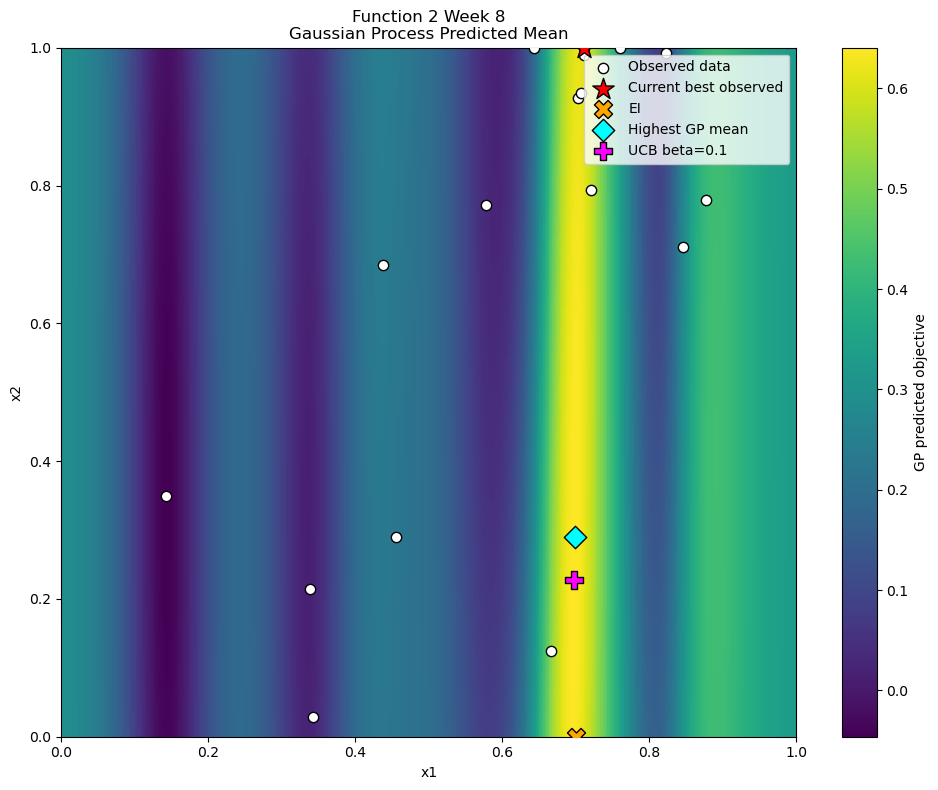

In [37]:
# --------------------------------------------------
# Function 2 Week 8 - GP predicted mean heat map
# --------------------------------------------------

# Create a dense grid across the full 2D domain
x1_plot = np.linspace(0, 1, 400)
x2_plot = np.linspace(0, 1, 400)

X1_plot, X2_plot = np.meshgrid(
    x1_plot,
    x2_plot
)

plot_points = np.column_stack([
    X1_plot.ravel(),
    X2_plot.ravel()
])

# GP prediction across the complete domain
plot_mu, plot_sigma = gp.predict(
    plot_points,
    return_std=True
)

MU = plot_mu.reshape(X1_plot.shape)

# Important Week 8 candidate locations
ei_candidate = np.array([
    0.69958247,
    0.00000000
])

mean_candidate = np.array([
    0.69837926,
    0.29000000
])

ucb_candidate = np.array([
    0.69805111,
    0.22700000
])

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 8))

heat = plt.pcolormesh(
    X1_plot,
    X2_plot,
    MU,
    shading="auto",
    cmap="viridis"
)

plt.colorbar(
    heat,
    label="GP predicted objective"
)

# All accumulated observations
plt.scatter(
    X[:, 0],
    X[:, 1],
    c="white",
    edgecolors="black",
    s=55,
    label="Observed data",
    zorder=4
)

# Current best observation
plt.scatter(
    best_x[0],
    best_x[1],
    marker="*",
    s=260,
    c="red",
    edgecolors="black",
    label="Current best observed",
    zorder=6
)

# Global EI point
plt.scatter(
    ei_candidate[0],
    ei_candidate[1],
    marker="X",
    s=170,
    c="orange",
    edgecolors="black",
    label="EI",
    zorder=6
)

# Highest GP mean
plt.scatter(
    mean_candidate[0],
    mean_candidate[1],
    marker="D",
    s=130,
    c="cyan",
    edgecolors="black",
    label="Highest GP mean",
    zorder=6
)

# Final low-exploration UCB point
plt.scatter(
    ucb_candidate[0],
    ucb_candidate[1],
    marker="P",
    s=180,
    c="magenta",
    edgecolors="black",
    label="UCB beta=0.1",
    zorder=7
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title(
    "Function 2 Week 8\n"
    "Gaussian Process Predicted Mean"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend(
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()

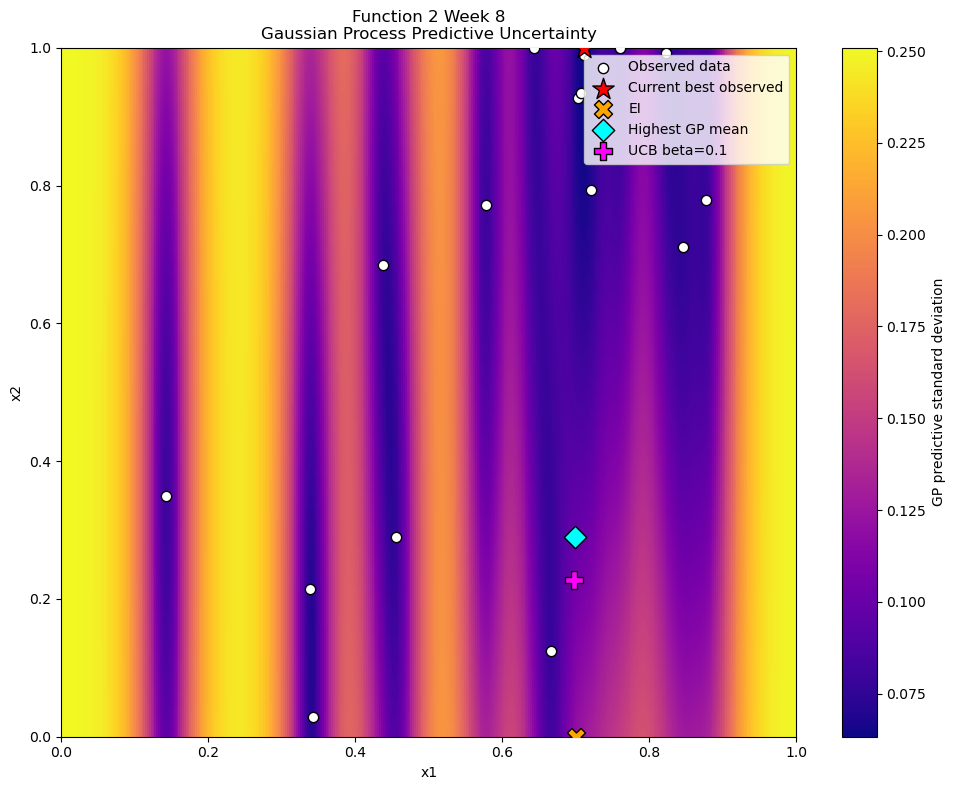

In [38]:
# --------------------------------------------------
# Function 2 Week 8 - GP uncertainty heat map
# --------------------------------------------------

SIGMA = plot_sigma.reshape(X1_plot.shape)

plt.figure(figsize=(10, 8))

heat = plt.pcolormesh(
    X1_plot,
    X2_plot,
    SIGMA,
    shading="auto",
    cmap="plasma"
)

plt.colorbar(
    heat,
    label="GP predictive standard deviation"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c="white",
    edgecolors="black",
    s=55,
    label="Observed data",
    zorder=4
)

plt.scatter(
    best_x[0],
    best_x[1],
    marker="*",
    s=260,
    c="red",
    edgecolors="black",
    label="Current best observed",
    zorder=6
)

plt.scatter(
    ei_candidate[0],
    ei_candidate[1],
    marker="X",
    s=170,
    c="orange",
    edgecolors="black",
    label="EI",
    zorder=6
)

plt.scatter(
    mean_candidate[0],
    mean_candidate[1],
    marker="D",
    s=130,
    c="cyan",
    edgecolors="black",
    label="Highest GP mean",
    zorder=6
)

plt.scatter(
    ucb_candidate[0],
    ucb_candidate[1],
    marker="P",
    s=180,
    c="magenta",
    edgecolors="black",
    label="UCB beta=0.1",
    zorder=7
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title(
    "Function 2 Week 8\n"
    "Gaussian Process Predictive Uncertainty"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend(
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()